In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import os

from torch.utils.data import DataLoader, Dataset
import torch.utils.data as utils
from torchvision import transforms

import torch
import torch.nn as nn
import torch.optim as optim 
import torchvision
from loguru import logger

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.preprocessing import LabelEncoder

from nazi_symbols_classification.training.data_preparation import get_image_paths
%matplotlib inline

In [3]:
dataset_path = "/home/zhiwei/Projects/nazi-symbols-classification/datasets/nazi-symbols-classification"

In [4]:
def load_labels_df(dataset_path, sub_dataset_name):
    image_paths = get_image_paths(dataset_path, sub_folders=(sub_dataset_name,))
    logger.info(f"Number of images in {sub_dataset_name} is {len(image_paths)}")
    training_image_paths = [image.removeprefix(f"os.path.join(dataset_path, sub_dataset_name)/") for image in image_paths]
    training_labels = [os.path.basename(os.path.dirname(image)) for image in training_image_paths]
    labels = pd.DataFrame(dict(path=training_image_paths, nazi_cls=training_labels))
    return labels

In [5]:
train_labels_df = load_labels_df(dataset_path, "train")

2025-04-01 22:22:20.865 | INFO     | __main__:load_labels_df:3 - Number of images in train is 9009


In [6]:
valid_labels_df = load_labels_df(dataset_path, "val")

2025-04-01 22:22:20.901 | INFO     | __main__:load_labels_df:3 - Number of images in val is 1934


In [7]:
test_labels_df = load_labels_df(dataset_path, "test")

2025-04-01 22:22:20.959 | INFO     | __main__:load_labels_df:3 - Number of images in test is 1944


In [8]:
le = LabelEncoder()

le.fit(train_labels_df.nazi_cls)
train_labels_df["nazi_cls_encoded"] = le.transform(train_labels_df.nazi_cls)
valid_labels_df["nazi_cls_encoded"] = le.transform(valid_labels_df.nazi_cls)
test_labels_df["nazi_cls_encoded"] = le.transform(test_labels_df.nazi_cls)

In [9]:
class ImageData(Dataset):
    def __init__(self, df, data_directory, transform):
        super().__init__()
        self.df = df
        self.data_directory = data_directory
        self.transform = transform

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):       
        img_name = self.df.path[index]
        label = self.df.nazi_cls_encoded[index]
        
        img_path = os.path.join(self.data_directory, img_name)
        try:
            image = mpimg.imread(img_path)
        except Exception:
            if img_path.endswith(".png"):
                image = mpimg.imread(img_path, format="jpg")
            else:
                image = mpimg.imread(img_path, format="png")
        image = self.transform(image)
        return image, label

In [10]:
data_transf = transforms.Compose([transforms.ToPILImage(), 
                                  transforms.Grayscale(num_output_channels=3),
                                  transforms.Resize((224, 224)), 
                                  transforms.ToTensor(),
                                  transforms.Normalize((0.5,), (0.5,))])

def create_datasets(batch_size, dataset_path=dataset_path):
    train_data = ImageData(df = train_labels_df,
                           data_directory = os.path.join(dataset_path, 'train'),
                           transform = data_transf)
    train_loader = DataLoader(dataset = train_data, batch_size = batch_size, shuffle=True)
    
    valid_data = ImageData(df = valid_labels_df, 
                           data_directory = os.path.join(dataset_path, 'val'), 
                           transform = data_transf)
    valid_loader = DataLoader(dataset = valid_data, batch_size = batch_size, shuffle=False)

    test_data = ImageData(df = test_labels_df, 
                           data_directory = os.path.join(dataset_path, 'test'), 
                           transform = data_transf)
    test_loader = DataLoader(dataset = test_data, batch_size = batch_size, shuffle=False)
    return train_loader, valid_loader, test_loader

In [11]:
batch_size = 16

train_loader, test_loader, valid_loader = create_datasets(batch_size, dataset_path)

### Data Sanity Check

tensor([ 1, 11,  1, 11, 18,  7, 17,  7, 20, 20, 17, 20, 20, 20,  1, 20])


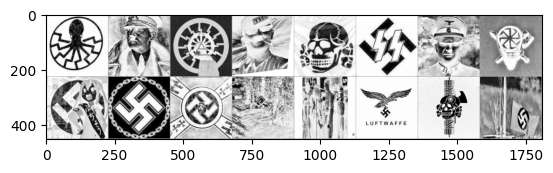

In [12]:
# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(train_loader)
images, labels = next(dataiter)

print(labels)

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)

In [13]:
from efficientnet_pytorch import EfficientNet
model = EfficientNet.from_name('efficientnet-b1')

In [14]:
# Unfreezing model weights
for param in model.parameters():
    param.requires_grad = True

In [15]:
num_ftrs = model._fc.in_features
model._fc = nn.Linear(num_ftrs, 1)

In [16]:
model = model.to('cuda')

In [17]:
optimizer = torch.optim.Adam(model.parameters())

In [18]:
loss_fn = nn.CrossEntropyLoss()

In [19]:
from early_stopping_pytorch import EarlyStopping


def train_model(model, batch_size, patience, n_epochs):
    
    # to track the training loss as the model trains
    train_losses = []
    # to track the validation loss as the model trains
    valid_losses = []
    # to track the average training loss per epoch as the model trains
    avg_train_losses = []
    # to track the average validation loss per epoch as the model trains
    avg_valid_losses = [] 
    
    # initialize the early_stopping object
    early_stopping = EarlyStopping(patience=patience, verbose=True)
    
    for epoch in range(n_epochs):

        ###################
        # train the model #
        ###################
        model.train() # prep model for training
        for i, (data, target) in enumerate(train_loader):
            # Every data instance is an input + label pair
            data, target = data.cuda(), target.cuda()
            target = target.float()                
            target = target.unsqueeze(1)
    
            # Zero your gradients for every batch!
            optimizer.zero_grad()
    
            # Make predictions for this batch
            output = model(data)
    
            # Compute the loss and its gradients
            loss = loss_fn(output, target)
            loss.backward()
    
            # Adjust learning weights
            optimizer.step()
            # record training loss
            train_losses.append(loss.item())

        ######################    
        # validate the model #
        ######################
        model.eval() # prep model for evaluation
        for data, target in valid_loader:
            data, target = data.cuda(), target.cuda()
            target = target.float()                
            target = target.unsqueeze(1)
            # forward pass: compute predicted outputs by passing inputs to the model
            output = model(data)
            # calculate the loss
            loss = loss_fn(output, target)
            # record validation loss
            valid_losses.append(loss.item())

        # print training/validation statistics 
        # calculate average loss over an epoch
        train_loss = np.average(train_losses)
        valid_loss = np.average(valid_losses)
        avg_train_losses.append(train_loss)
        avg_valid_losses.append(valid_loss)
        
        epoch_len = len(str(n_epochs))
        
        print_msg = (f'[{(epoch + 1):>{epoch_len}}/{(n_epochs + 1):>{epoch_len}}] ' +
                     f'train_loss: {train_loss:.5f} ' +
                     f'valid_loss: {valid_loss:.5f}')
        
        print(print_msg)
        
        # clear lists to track next epoch
        train_losses = []
        valid_losses = []
        
        # early_stopping needs the validation loss to check if it has decresed, 
        # and if it has, it will make a checkpoint of the current model
        early_stopping(valid_loss, model)
        
        if early_stopping.early_stop:
            print("Early stopping")
            break
        
    # load the last checkpoint with the best model
    model.load_state_dict(torch.load('checkpoint.pt', weights_only=True))

    return  model, avg_train_losses, avg_valid_losses

In [20]:
%%time
# Training model for 5 epochs and logging the time required for the entire training process
# Initializing in a separate cell so we can easily add more epochs to the same run
n_epochs = 100

# early stopping patience; how long to wait after last time validation loss improved.
patience = 20

model, train_loss, valid_loss = train_model(model, batch_size, patience, n_epochs)

[  1/101] train_loss: 0.00000 valid_loss: 0.00000
Validation loss decreased (inf --> 0.000000).  Saving model ...
[  2/101] train_loss: 0.00000 valid_loss: 0.00000
EarlyStopping counter: 1 out of 20
[  3/101] train_loss: 0.00000 valid_loss: 0.00000
EarlyStopping counter: 2 out of 20
[  4/101] train_loss: 0.00000 valid_loss: 0.00000
EarlyStopping counter: 3 out of 20
[  5/101] train_loss: 0.00000 valid_loss: 0.00000
EarlyStopping counter: 4 out of 20
[  6/101] train_loss: 0.00000 valid_loss: 0.00000
EarlyStopping counter: 5 out of 20
[  7/101] train_loss: 0.00000 valid_loss: 0.00000
EarlyStopping counter: 6 out of 20
[  8/101] train_loss: 0.00000 valid_loss: 0.00000
EarlyStopping counter: 7 out of 20
[  9/101] train_loss: 0.00000 valid_loss: 0.00000
EarlyStopping counter: 8 out of 20
[ 10/101] train_loss: 0.00000 valid_loss: 0.00000
EarlyStopping counter: 9 out of 20
[ 11/101] train_loss: 0.00000 valid_loss: 0.00000
EarlyStopping counter: 10 out of 20
[ 12/101] train_loss: 0.00000 valid